In [ ]:
!pip install -q torch torchvision numpy opencv-python scipy scikit-image tqdm


In [12]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import zoom
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm


In [13]:
!wget -O RealESRGAN_x4plus.pth \
https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth

assert os.path.exists("RealESRGAN_x4plus.pth"), "Download failed"
print("Weights size (MB):", os.path.getsize("RealESRGAN_x4plus.pth") / 1e6)


--2025-12-14 06:13:46--  https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/387326890/08f0e941-ebb7-48f0-9d6a-73e87b710e7e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-14T07%3A07%3A22Z&rscd=attachment%3B+filename%3DRealESRGAN_x4plus.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-14T06%3A07%3A01Z&ske=2025-12-14T07%3A07%3A22Z&sks=b&skv=2018-11-09&sig=FBjLP9g0ACK32vA9RwE073bi2b2MJOBEmToDWdT6cjk%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2NTY5NDYyNiwibmJmIjoxNzY1NjkyODI2LCJwYXRoIjoicmVsZWFzZWFzc2V0cH

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class ResidualDenseBlock(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1)
        self.conv2 = nn.Conv2d(nf+gc, gc, 3, 1, 1)
        self.conv3 = nn.Conv2d(nf+2*gc, gc, 3, 1, 1)
        self.conv4 = nn.Conv2d(nf+3*gc, gc, 3, 1, 1)
        self.conv5 = nn.Conv2d(nf+4*gc, nf, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], 1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], 1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], 1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], 1))
        return x + x5 * 0.2


class RRDB(nn.Module):
    def __init__(self, nf):
        super().__init__()
        self.rdb1 = ResidualDenseBlock(nf)
        self.rdb2 = ResidualDenseBlock(nf)
        self.rdb3 = ResidualDenseBlock(nf)

    def forward(self, x):
        return x + self.rdb3(self.rdb2(self.rdb1(x))) * 0.2


class RealESRGANGenerator(nn.Module):
    def __init__(self, nf=64, nb=23):
        super().__init__()
        self.conv_first = nn.Conv2d(3, nf, 3, 1, 1)
        self.body = nn.Sequential(*[RRDB(nf) for _ in range(nb)])
        self.conv_body = nn.Conv2d(nf, nf, 3, 1, 1)

        self.conv_up1 = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_up2 = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_hr = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_last = nn.Conv2d(nf, 3, 3, 1, 1)

        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.conv_body(self.body(fea))
        fea = fea + trunk

        fea = self.lrelu(self.conv_up1(F.interpolate(fea, scale_factor=2, mode="nearest")))
        fea = self.lrelu(self.conv_up2(F.interpolate(fea, scale_factor=2, mode="nearest")))
        fea = self.lrelu(self.conv_hr(fea))
        return self.conv_last(fea)


In [15]:
model = RealESRGANGenerator().to(device)

ckpt = torch.load("RealESRGAN_x4plus.pth", map_location=device)
model.load_state_dict(ckpt["params_ema"], strict=True)

model.eval()
print("✅ Real-ESRGAN loaded correctly")


✅ Real-ESRGAN loaded correctly


In [16]:
def realesrgan_x4(img_rgb):
    img = torch.from_numpy(img_rgb.astype(np.float32) / 255.0)
    img = img.permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img)

    out = out.squeeze().cpu().numpy().transpose(1, 2, 0)
    out = np.clip(out * 255.0, 0, 255).astype(np.uint8)
    return out


In [ ]:
import os
import cv2
import numpy as np
from scipy.ndimage import zoom
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

ORIGINAL_DIR = "original"
DOWNSIZED_DIR = "downsized"
OUTPUT_DIR = "outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
for m in ["bicubic_opencv", "bicubic_scipy", "realesrgan"]:
    os.makedirs(f"{OUTPUT_DIR}/{m}", exist_ok=True)

def sharpness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def edge_strength(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0)
    sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1)
    return np.sqrt(sx**2 + sy**2).mean()

def entropy(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0,256]).ravel()
    hist /= hist.sum()
    hist = hist[hist > 0]
    return -(hist * np.log2(hist)).sum()

metrics = {
    "bicubic_opencv": {"psnr": [], "ssim": [], "sharp": [], "edge": [], "entropy": []},
    "bicubic_scipy":  {"psnr": [], "ssim": [], "sharp": [], "edge": [], "entropy": []},
    "realesrgan":     {"psnr": [], "ssim": [], "sharp": [], "edge": [], "entropy": []},
}

files = sorted(os.listdir(ORIGINAL_DIR))

for fname in tqdm(files):
    if not fname.lower().endswith(".jpeg"):
        continue

    base = fname.replace(".jpeg", "")
    down_name = f"{base}_downsized.jpeg"

    gt = cv2.cvtColor(cv2.imread(f"{ORIGINAL_DIR}/{fname}"), cv2.COLOR_BGR2RGB)
    lr = cv2.cvtColor(cv2.imread(f"{DOWNSIZED_DIR}/{down_name}"), cv2.COLOR_BGR2RGB)

    H, W = gt.shape[:2]

    bic_cv = cv2.resize(lr, (W, H), interpolation=cv2.INTER_CUBIC)
    cv2.imwrite(f"{OUTPUT_DIR}/bicubic_opencv/{fname}",
                cv2.cvtColor(bic_cv, cv2.COLOR_RGB2BGR))

    metrics["bicubic_opencv"]["psnr"].append(psnr(gt, bic_cv, data_range=255))
    metrics["bicubic_opencv"]["ssim"].append(ssim(gt, bic_cv, channel_axis=2, data_range=255))
    metrics["bicubic_opencv"]["sharp"].append(sharpness(bic_cv))
    metrics["bicubic_opencv"]["edge"].append(edge_strength(bic_cv))
    metrics["bicubic_opencv"]["entropy"].append(entropy(bic_cv))

    bic_sp = zoom(lr, (4, 4, 1), order=3)
    bic_sp = cv2.resize(bic_sp, (W, H)).astype(np.uint8)

    cv2.imwrite(f"{OUTPUT_DIR}/bicubic_scipy/{fname}",
                cv2.cvtColor(bic_sp, cv2.COLOR_RGB2BGR))

    metrics["bicubic_scipy"]["psnr"].append(psnr(gt, bic_sp, data_range=255))
    metrics["bicubic_scipy"]["ssim"].append(ssim(gt, bic_sp, channel_axis=2, data_range=255))
    metrics["bicubic_scipy"]["sharp"].append(sharpness(bic_sp))
    metrics["bicubic_scipy"]["edge"].append(edge_strength(bic_sp))
    metrics["bicubic_scipy"]["entropy"].append(entropy(bic_sp))

    sr = realesrgan_x4(lr)
    sr = cv2.resize(sr, (W, H))

    cv2.imwrite(f"{OUTPUT_DIR}/realesrgan/{fname}",
                cv2.cvtColor(sr, cv2.COLOR_RGB2BGR))

    metrics["realesrgan"]["psnr"].append(psnr(gt, sr, data_range=255))
    metrics["realesrgan"]["ssim"].append(ssim(gt, sr, channel_axis=2, data_range=255))
    metrics["realesrgan"]["sharp"].append(sharpness(sr))
    metrics["realesrgan"]["edge"].append(edge_strength(sr))
    metrics["realesrgan"]["entropy"].append(entropy(sr))

print("\n===== DATASET AVERAGE RESULTS =====")
for method, vals in metrics.items():
    print(f"\n{method}")
    print(f" PSNR:      {np.mean(vals['psnr']):.3f}")
    print(f" SSIM:      {np.mean(vals['ssim']):.4f}")
    print(f" Sharpness: {np.mean(vals['sharp']):.2f}")
    print(f" Edge Str.: {np.mean(vals['edge']):.2f}")
    print(f" Entropy:   {np.mean(vals['entropy']):.4f}")


100%|██████████| 5/5 [00:39<00:00,  7.87s/it]


===== DATASET AVERAGE RESULTS =====

bicubic_opencv
 PSNR:      20.019
 SSIM:      0.7079
 Sharpness: 5.05
 Edge Str.: 19.95
 Entropy:   7.4419

bicubic_scipy
 PSNR:      19.767
 SSIM:      0.7035
 Sharpness: 4.60
 Edge Str.: 19.61
 Entropy:   7.4378

realesrgan
 PSNR:      18.466
 SSIM:      0.6506
 Sharpness: 99.57
 Edge Str.: 28.81
 Entropy:   7.4306


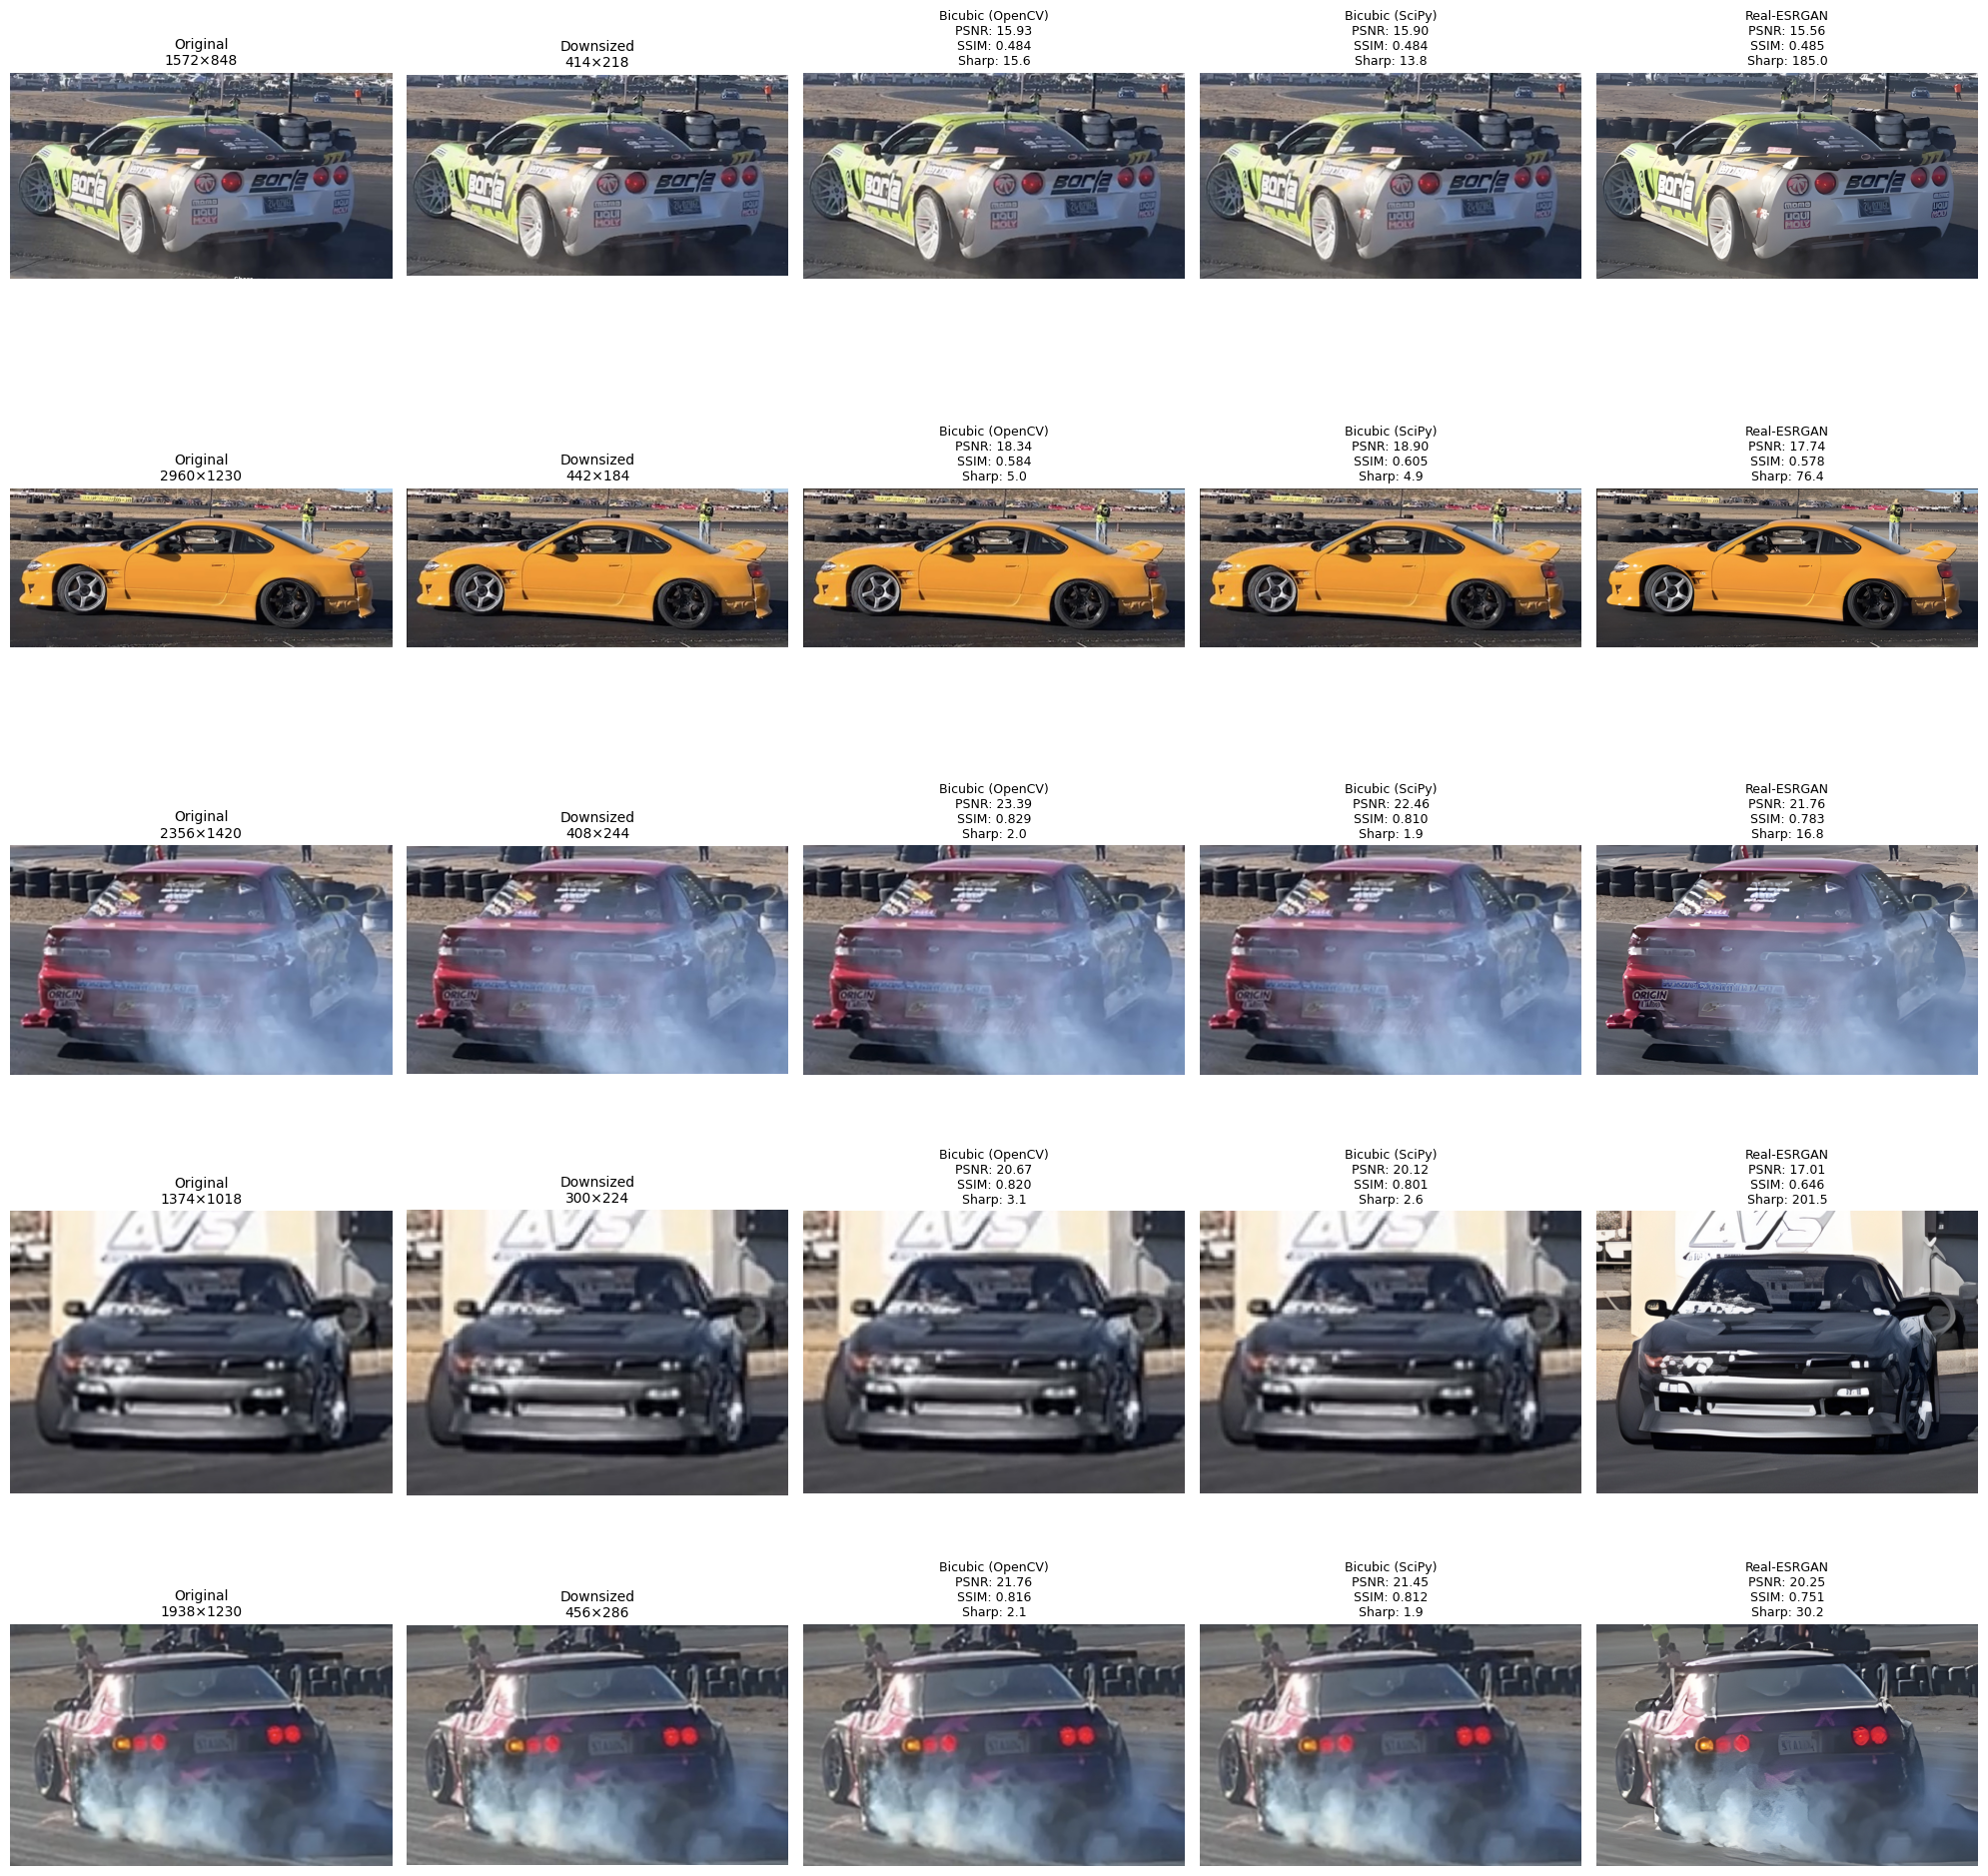

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def sharpness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


image_ids = ["f1", "f2", "f3", "f4", "f5"]

fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for row, img_id in enumerate(image_ids):
    # Load images
    gt = cv2.cvtColor(cv2.imread(f"original/{img_id}.jpeg"), cv2.COLOR_BGR2RGB)
    lr = cv2.cvtColor(cv2.imread(f"downsized/{img_id}_downsized.jpeg"), cv2.COLOR_BGR2RGB)

    bic_cv = cv2.cvtColor(cv2.imread(f"outputs/bicubic_opencv/{img_id}.jpeg"), cv2.COLOR_BGR2RGB)
    bic_sp = cv2.cvtColor(cv2.imread(f"outputs/bicubic_scipy/{img_id}.jpeg"), cv2.COLOR_BGR2RGB)
    esr = cv2.cvtColor(cv2.imread(f"outputs/realesrgan/{img_id}.jpeg"), cv2.COLOR_BGR2RGB)

    images = [gt, lr, bic_cv, bic_sp, esr]
    titles = [
        f"Original\n{gt.shape[1]}×{gt.shape[0]}",
        f"Downsized\n{lr.shape[1]}×{lr.shape[0]}",
        "Bicubic (OpenCV)",
        "Bicubic (SciPy)",
        "Real-ESRGAN"
    ]

    for col, img in enumerate(images):
        ax = axes[row, col]
        ax.imshow(img)
        ax.axis("off")

        if col < 2:
            ax.set_title(titles[col], fontsize=10)

        else:
            p = psnr(gt, img, data_range=255)
            s = ssim(gt, img, channel_axis=2, data_range=255)
            sh = sharpness(img)

            ax.set_title(
                f"{titles[col]}\n"
                f"PSNR: {p:.2f}\n"
                f"SSIM: {s:.3f}\n"
                f"Sharp: {sh:.1f}",
                fontsize=9
            )

plt.tight_layout()
plt.show()


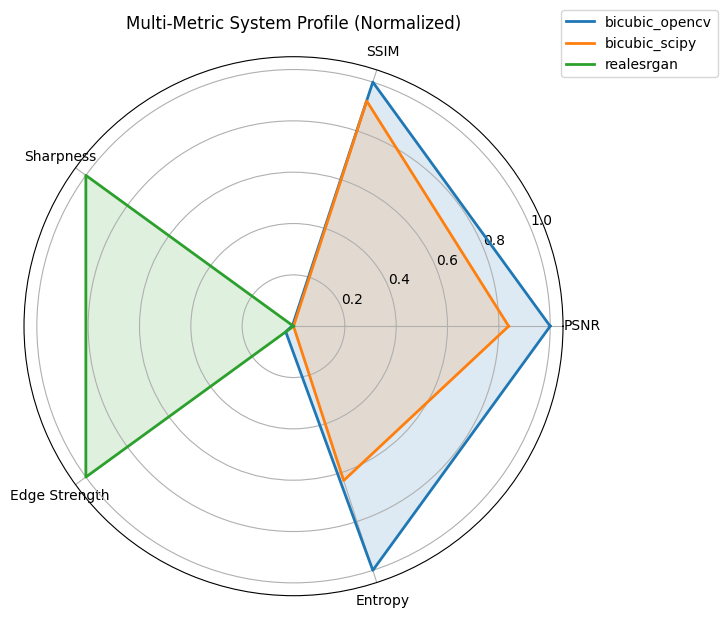

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics_list = ["psnr", "ssim", "sharp", "edge", "entropy"]
labels = ["PSNR", "SSIM", "Sharpness", "Edge Strength", "Entropy"]

data = {}
for m in metrics:
    data[m] = [np.mean(metrics[m][k]) for k in metrics_list]

data_arr = np.array(list(data.values()))
data_norm = (data_arr - data_arr.min(axis=0)) / (data_arr.max(axis=0) - data_arr.min(axis=0))

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for i, m in enumerate(metrics.keys()):
    vals = data_norm[i].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=m)
    ax.fill(angles, vals, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("Multi-Metric System Profile (Normalized)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()


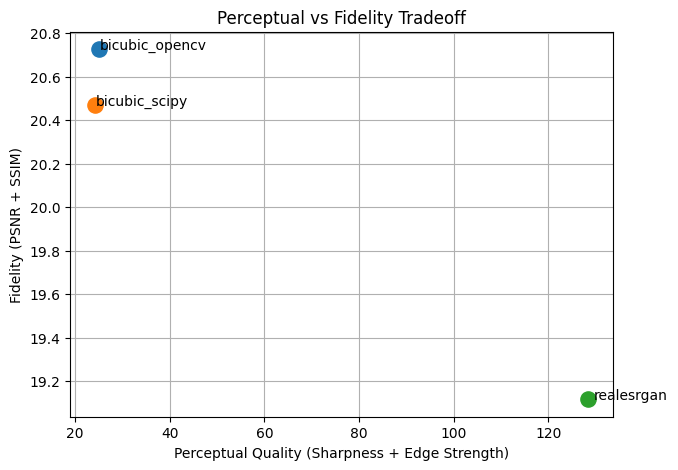

In [22]:
fidelity = {}
perceptual = {}

for m in metrics:
    fidelity[m] = np.mean(metrics[m]["psnr"]) + np.mean(metrics[m]["ssim"])
    perceptual[m] = np.mean(metrics[m]["sharp"]) + np.mean(metrics[m]["edge"])

plt.figure(figsize=(7,5))
for m in metrics:
    plt.scatter(perceptual[m], fidelity[m], s=120)
    plt.text(perceptual[m]*1.01, fidelity[m], m, fontsize=10)

plt.xlabel("Perceptual Quality (Sharpness + Edge Strength)")
plt.ylabel("Fidelity (PSNR + SSIM)")
plt.title("Perceptual vs Fidelity Tradeoff")
plt.grid(True)
plt.show()


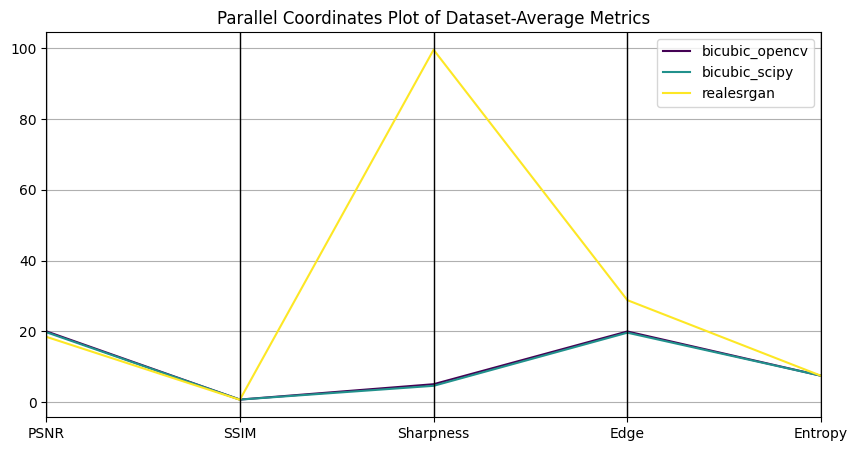

In [23]:
from pandas import DataFrame
from pandas.plotting import parallel_coordinates

rows = []
for m in metrics:
    row = {
        "Method": m,
        "PSNR": np.mean(metrics[m]["psnr"]),
        "SSIM": np.mean(metrics[m]["ssim"]),
        "Sharpness": np.mean(metrics[m]["sharp"]),
        "Edge": np.mean(metrics[m]["edge"]),
        "Entropy": np.mean(metrics[m]["entropy"])
    }
    rows.append(row)

df = DataFrame(rows)

plt.figure(figsize=(10,5))
parallel_coordinates(df, "Method", colormap="viridis")
plt.title("Parallel Coordinates Plot of Dataset-Average Metrics")
plt.grid(True)
plt.show()
